# 02 — Minimal Reproducible NOAA POES Loader (Checkpoint 2)

Download one real **NOAA-19 L1b processed NetCDF** file from the official NCEI archive, open it
with xarray, extract a tidy one-day table (`time, lat, lon, alt, satellite, source_file,
mep_omni_flux_p1` + quality flags), run sanity checks, and save it to `data/processed/`.

**This notebook is executed end-to-end on real data — the outputs below are real, not fabricated.**
No SAA map and no scientific interpretation in this checkpoint.

The variable mapping and the real-file quirks are documented in `src/saa/load_poes.py` and in
`docs/research_notes.md` (Checkpoint 2 section).

In [1]:
import os, sys, pathlib
import numpy as np
import pandas as pd
from IPython.display import display

cwd = pathlib.Path.cwd()
ROOT = cwd.parent if cwd.name == "notebooks" else cwd
sys.path.insert(0, str(ROOT / "src"))

RAW_DIR = ROOT / "data" / "raw"
PROC_DIR = ROOT / "data" / "processed"

DATE = "2024-01-01"
SATELLITE = "noaa19"
CHANNEL = "mep_omni_flux_p1"

print("project root :", ROOT)
print("python       :", sys.version.split()[0])
print("pandas       :", pd.__version__)

project root : /home/fellipe/Projects/Active/saa-poes-mapping
python       : 3.12.13
pandas       : 3.0.3


## Step 1 — Build the official NCEI URL and download (only if missing)

In [2]:
from saa.load_poes import build_poes_l1b_url, download_poes_file, file_sha256

url = build_poes_l1b_url(DATE, SATELLITE)
print("URL:", url)

nc_path = download_poes_file(DATE, SATELLITE, output_dir=str(RAW_DIR))
print("local file  :", nc_path)
print("size (bytes):", os.path.getsize(nc_path))
print("sha256      :", file_sha256(nc_path))

URL: https://www.ncei.noaa.gov/data/poes-metop-space-environment-monitor/access/l1b/v01r00/2024/noaa19/poes_n19_20240101_proc.nc
local file  : /home/fellipe/Projects/Active/saa-poes-mapping/data/raw/poes_n19_20240101_proc.nc
size (bytes): 5800360
sha256      : 45b84acd431025ef0abb3c87a81735c9364f155e97fb3a264848dd9d85be8e3c


## Step 2 — Open the NetCDF file and inspect dimensions / variables

In [3]:
from saa.load_poes import open_poes_netcdf, describe_dataset

ds = open_poes_netcdf(nc_path)
summary = describe_dataset(ds)

print("records         :", summary["n_records"])
print("total variables :", summary["n_variables"])
print("global title    :", summary["global_title"])
print("time resolution :", summary["time_coverage_resolution"])
print("longitude units :", summary["geospatial_lon_units"])
print()
print("first 12 variables:", summary["variables_preview"])
print()
print("key variable attributes (name | dtype | units | long_name):")
for v, info in summary["key_var_attrs"].items():
    print("  %-24s %-8s %-22s %s" % (v, info["dtype"], repr(info["units"]), info["long_name"]))

records         : 43197
total variables : 158
global title    : POES/MetOp: Particle Precipitation (These data have known contamination problems. Please consult provider for usage recommendations.)
time resolution : 2sec
longitude units : degrees East

first 12 variables: ['time', 'year', 'day', 'msec', 'satID', 'sat_direction', 'alt', 'lat', 'lon', 'mep_pro_tel0_flux_p1', 'mep_pro_tel0_flux_p2', 'mep_pro_tel0_flux_p3']

key variable attributes (name | dtype | units | long_name):
  time                     uint64   'time'                 milliseconds since 1970
  lat                      float32  'degrees'              latitude of the satellite
  lon                      float32  'degrees'              longitude of the satellite
  alt                      float32  'km'                   altitude of the satellite
  satID                    uint8    'ID'                   2 digit number identifying the satellite the data is from
  mep_omni_flux_p1         float32  '#/cm2-s-str-MeV'      

## Step 3 — Extract the tidy minimal DataFrame

Mapping used (implemented in `src/saa/load_poes.py`):

| tidy column | source NetCDF variable | transform |
|---|---|---|
| `time` | `time` (uint64) | epoch **ms since 1970** -> `pd.to_datetime(unit="ms", utc=True)` |
| `lat` | `lat` | float32 -> float64, degrees |
| `lon` | `lon` | float32 -> float64, **[0,360) East** |
| `alt` | `alt` | float32 -> float64, km |
| `satellite` | (filename token `n19`) | constant label `noaa19` |
| `source_file` | (filename) | basename |
| `mep_omni_flux_p1` | `mep_omni_flux_p1` | differential proton flux @ ~25 MeV, `#/cm2-s-str-MeV` |
| `mep_IFC_on` | `mep_IFC_on` | int flag carried through (raw {-1,0}); mask `==1` later |
| `mep_omni_flux_flag_fit` | `mep_omni_flux_flag_fit` | omni fit-quality flag carried through |

In [4]:
from saa.load_poes import extract_minimal_dataframe, CHANNEL_INFO

df = extract_minimal_dataframe(ds, nc_path, satellite=SATELLITE, channel=CHANNEL)
print("shape:", df.shape)
print("channel:", CHANNEL, "->", CHANNEL_INFO.get(CHANNEL))
print()
print("dtypes:")
print(df.dtypes)
display(df.head())

shape: (43197, 9)
channel: mep_omni_flux_p1 -> ('MEPED omni proton differential flux @ ~25 MeV', '#/cm2-s-str-MeV')

dtypes:
time                      datetime64[ms, UTC]
lat                                   float64
lon                                   float64
alt                                   float64
satellite                                 str
source_file                               str
mep_omni_flux_p1                      float64
mep_IFC_on                              int16
mep_omni_flux_flag_fit                  int16
dtype: object


,time,lat,lon,alt,satellite,source_file,mep_omni_flux_p1,mep_IFC_on,mep_omni_flux_flag_fit
0,2024-01-01 00:00:00.977000+00:00,71.722000,163.423996,855.5,noaa19,poes_n19_20240101_proc.nc,0.0211,-1,1
1,2024-01-01 00:00:02.977000+00:00,71.620003,163.229004,855.5,noaa19,poes_n19_20240101_proc.nc,0.0054,-1,1
2,2024-01-01 00:00:04.976000+00:00,71.517998,163.035995,855.5,noaa19,poes_n19_20240101_proc.nc,0.0000,-1,1
3,2024-01-01 00:00:06.976000+00:00,71.416000,162.845001,855.5,noaa19,poes_n19_20240101_proc.nc,0.0603,-1,1
4,2024-01-01 00:00:08.976000+00:00,71.313004,162.656006,855.5,noaa19,poes_n19_20240101_proc.nc,0.0599,-1,1


## Step 4 — Sanity checks (rows, missing values, coordinate & time ranges)

In [5]:
print("row count:", len(df))
print()
print("missing values per column:")
print(df.isna().sum())
print()
miss_pct = df[CHANNEL].isna().mean() * 100.0
print("missing %% for %s: %.4f%%" % (CHANNEL, miss_pct))
print()
print("latitude  min/max : %.4f / %.4f" % (df["lat"].min(), df["lat"].max()))
print("longitude min/max : %.4f / %.4f" % (df["lon"].min(), df["lon"].max()))
lon_conv = "[0, 360)" if (df["lon"].min() >= 0 and df["lon"].max() > 180) else "[-180, 180]"
print("longitude convention:", lon_conv)
print("altitude  min/max : %.2f / %.2f km" % (df["alt"].min(), df["alt"].max()))
print()
print("timestamp range:", df["time"].min(), "->", df["time"].max())
print()
print("numeric summary:")
display(df[["lat", "lon", "alt", CHANNEL]].describe())
if "mep_IFC_on" in df.columns:
    print()
    print("mep_IFC_on value counts (raw; long_name says 0=off/1=on, -1=fill):")
    print(df["mep_IFC_on"].value_counts(dropna=False))
if "mep_omni_flux_flag_fit" in df.columns:
    print()
    print("mep_omni_flux_flag_fit value counts (0/1/2):")
    print(df["mep_omni_flux_flag_fit"].value_counts(dropna=False))

row count: 43197

missing values per column:
time                      0
lat                       0
lon                       0
alt                       0
satellite                 0
source_file               0
mep_omni_flux_p1          0
mep_IFC_on                0
mep_omni_flux_flag_fit    0
dtype: int64

missing % for mep_omni_flux_p1: 0.0000%

latitude  min/max : -80.9740 / 80.9740
longitude min/max : 0.0070 / 359.9970
longitude convention: [0, 360)
altitude  min/max : 842.30 / 886.60 km

timestamp range: 2024-01-01 00:00:00.977000+00:00 -> 2024-01-01 23:59:56.975000+00:00

numeric summary:


,lat,lon,alt,mep_omni_flux_p1
count,43197.000000,43197.000000,43197.000000,43197.000000
mean,0.284680,179.452485,861.275917,0.586124
std,50.187101,103.571458,13.645479,3.046508
min,-80.973999,0.007000,842.299988,0.000000
25%,-44.257999,90.210999,851.900024,0.005400
50%,0.518000,178.548004,855.799988,0.017200
75%,44.896999,268.635986,872.900024,0.038500
max,80.973999,359.997009,886.599976,36.568699



mep_IFC_on value counts (raw; long_name says 0=off/1=on, -1=fill):
mep_IFC_on
-1    40497
 0     2700
Name: count, dtype: int64

mep_omni_flux_flag_fit value counts (0/1/2):
mep_omni_flux_flag_fit
1    36055
2     3656
0     3486
Name: count, dtype: int64


## Step 5 — Save the processed one-day table (parquet, CSV fallback)

In [6]:
PROC_DIR.mkdir(parents=True, exist_ok=True)
proc_stem = PROC_DIR / ("%s_%s_%s" % (SATELLITE, DATE, CHANNEL))

fmt = None
saved_path = None
try:
    saved_path = str(proc_stem.with_suffix(".parquet"))
    df.to_parquet(saved_path, index=False)
    fmt = "parquet"
except Exception as e:
    print("parquet save failed (%s); falling back to CSV" % e)
    saved_path = str(proc_stem.with_suffix(".csv"))
    df.to_csv(saved_path, index=False)
    fmt = "csv"

print("saved :", saved_path)
print("format:", fmt, "| size (bytes):", os.path.getsize(saved_path))

if fmt == "parquet":
    back = pd.read_parquet(saved_path)
else:
    back = pd.read_csv(saved_path, parse_dates=["time"])
print("reloaded shape:", back.shape, "| columns:", list(back.columns))
assert back.shape == df.shape, "round-trip shape mismatch"
print("round-trip OK")

saved : /home/fellipe/Projects/Active/saa-poes-mapping/data/processed/noaa19_2024-01-01_mep_omni_flux_p1.parquet
format: parquet | size (bytes): 1074994
reloaded shape: (43197, 9) | columns: ['time', 'lat', 'lon', 'alt', 'satellite', 'source_file', 'mep_omni_flux_p1', 'mep_IFC_on', 'mep_omni_flux_flag_fit']
round-trip OK


## Step 6 — Tiny diagnostic (sanity only — NOT the SAA map, no interpretation)

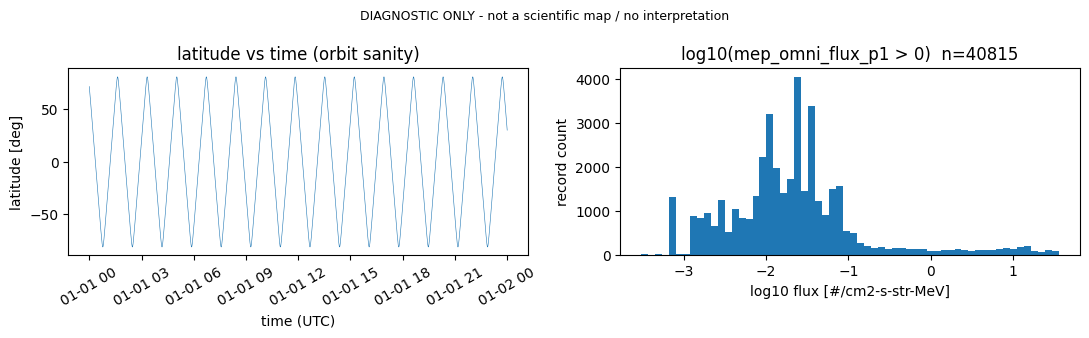

diagnostic figure saved: /home/fellipe/Projects/Active/saa-poes-mapping/data/processed/diagnostic_noaa19_2024-01-01.png


In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(df["time"].values, df["lat"].values, lw=0.4)
axes[0].set_title("latitude vs time (orbit sanity)")
axes[0].set_xlabel("time (UTC)")
axes[0].set_ylabel("latitude [deg]")
axes[0].tick_params(axis="x", rotation=30)

vals = df[CHANNEL].to_numpy()
pos = vals[vals > 0]
axes[1].hist(np.log10(pos), bins=60)
axes[1].set_title("log10(%s > 0)  n=%d" % (CHANNEL, pos.size))
axes[1].set_xlabel("log10 flux [#/cm2-s-str-MeV]")
axes[1].set_ylabel("record count")

fig.suptitle("DIAGNOSTIC ONLY - not a scientific map / no interpretation", fontsize=9)
fig.tight_layout()
diag_path = PROC_DIR / ("diagnostic_%s_%s.png" % (SATELLITE, DATE))
fig.savefig(diag_path, dpi=90)
plt.show()
print("diagnostic figure saved:", diag_path)
ds.close()

## Summary

Loaded a real NCEI NOAA-19 L1b NetCDF, extracted a tidy one-day table with **time, lat, lon, alt,
satellite, source_file, mep_omni_flux_p1** (+ quality flags), checked ranges / missing values, and
saved it to `data/processed/`. Validate independently with:

    python scripts/validate_processed_sample.py

Provenance: `data/processed/PROVENANCE.md`. **No scientific conclusions are drawn here.**
Next (Checkpoint 3): first exploratory lon x lat SAA map, masking `mep_IFC_on == 1`.